In [52]:
# Import libraries
import os
import glob
import numpy as np
import pandas as pd
import cv2

In [53]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [54]:
# Import custom definitions
from definitions import *

print(f"Dataset path: {data_root}")
print(f"Meta path: {meta_path}")
print(f"Mass training data path: {new_mass_train_path}")
print(f"Mass test data path: {new_mass_test_path}")
print(f"Mass train tensor path: {mass_train_tensor_path}")
print(f"Mass test tensor path: {mass_test_tensor_path}")

Dataset path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688
Meta path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/metadata.csv
Mass training data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_train_set.csv
Mass test data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_test_set.csv
Mass train tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/train
Mass test tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/test


# History

### Load history

In [55]:
history_df = pd.read_csv(os.path.join(data_root, 'history.csv'))

history_df.tail(2)

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
998,0.998365,0.821579,0.704679,0.097418,0.998389,0.848648,0.741631,0.085446,49
999,0.998373,0.822675,0.705044,0.097150,0.998362,0.847901,0.740598,0.086834,49


### Visualise history

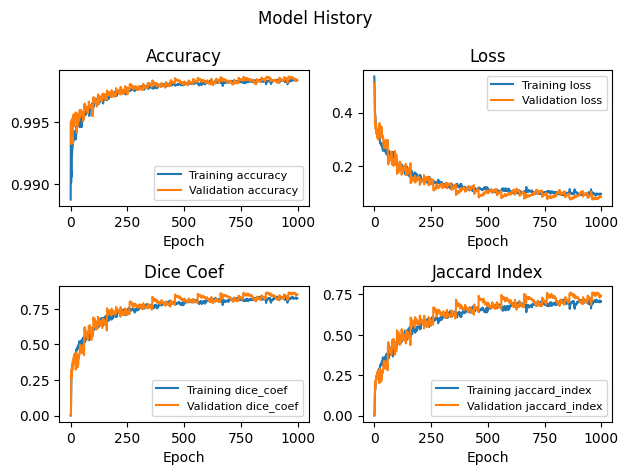

In [56]:
# Visualise model history
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Dice Coef
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Dice Coef
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

### Load model

In [57]:
from tensorflow.keras import backend as K

# Dice Loss for segmentation (handles class imbalance)
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice
    
# Combined Binary Cross-Entropy and Dice loss for stability + region similarity
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return bce + 5 * d_loss

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return 0.5 * bce + 0.5 * d_loss

# Dice Coefficient (Sørensen–Dice) for model evaluation
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Apply threshold
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return (2. * intersection + smooth) / (union + smooth)
    
# Jaccard index (Intersection over Union) metric
def jaccard_index(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    # Threshold predicted masks to get binary output
    y_pred = tf.cast(y_pred > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [58]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
class HnAdam(Adam):
    def __init__(self,
                 learning_rate=0.001,
                 beta_1=0.9,
                 beta_2=0.999,
                 epsilon=1e-7,
                 amsgrad=False,
                 norm_min=1e-7,
                 norm_max=10.0,
                 name="HnAdam",
                 **kwargs):
        super().__init__(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2,
                         epsilon=epsilon, amsgrad=amsgrad, name=name, **kwargs)
        self.norm_min = norm_min
        self.norm_max = norm_max

    def _resource_apply_dense(self, grad, var):
        # call Adam's update first to update m,v etc
        super()._resource_apply_dense(grad, var)

        # get slot variables m and v
        m = self.get_slot(var, "m")
        v = self.get_slot(var, "v")

        var_dtype = var.dtype.base_dtype
        epsilon_t = tf.convert_to_tensor(self.epsilon, var_dtype)

        m_hat = m / (1 - tf.pow(self.beta_1, tf.cast(self.iterations + 1, var_dtype)))
        v_hat = v / (1 - tf.pow(self.beta_2, tf.cast(self.iterations + 1, var_dtype)))

        norm = tf.norm(m_hat / (tf.sqrt(v_hat) + epsilon_t))
        clipped_norm = tf.clip_by_value(norm, self.norm_min, self.norm_max)
        lam = clipped_norm / 2.0

        lr_t = self._decayed_lr(var_dtype)

        update = m_hat / (tf.sqrt(v_hat) + epsilon_t)
        var.assign_sub(lr_t * update * lam)

In [59]:
# Load the saved model
loaded_model = tf.keras.models.load_model(
    os.path.join(data_root, 'mass_model.keras'),
    custom_objects={
        'combined_loss': combined_loss,
        'dice_coef': dice_coef,
        'jaccard_index': jaccard_index
})

### Model summary

In [60]:
loaded_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_3[

 Total params: 103,540,037 (394.97 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,026,692 (263.32 MB)

### Evaluation

In [61]:
test_images = tf.data.Dataset.load(mass_test_tensor_path)
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

test_rows = len(test_images)
val_size = int(0.8 * test_rows)
test_size = test_rows - val_size
BATCH_SIZE = 8

test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


In [62]:
evaluations = loaded_model.evaluate(test_batches)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9986 - dice_coef: 0.8380 - jaccard_index: 0.7358 - loss: 0.0883


In [63]:
print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

Evaluation with test dataset:
	Loss: 0.0789
	Accuracy: 99.87%


### Prediction

In [64]:
predictions = loaded_model.predict(test_batches)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


In [65]:
print(f"predictions size: {predictions.shape}")

predictions size: (76, 128, 128, 1)


In [66]:
from sklearn.metrics import classification_report

y_true_all = []
y_pred_all = []

for images, masks in test_batches:
    preds = loaded_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Apply threshold to predicted masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten both prediction and mask to compare pixel-wise
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Use sklearn classification report
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.88      0.85      0.86      6284

    accuracy                           1.00   1245184
   macro avg       0.94      0.92      0.93   1245184
weighted avg       1.00      1.00      1.00   1245184



In [67]:
def display(images):
    plt.figure(figsize=(7, 7))
    title = ["Input Image", "Ground Truth", "Predicted Mask"]
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(images[i]))
        plt.axis("off")
    plt.show()
    
def create_mask(pred_mask):
    if False:
        mask = tf.math.argmax(pred_mask, axis=-1)
        mask = mask[..., tf.newaxis]
    else:  
        mask = tf.cast(pred_mask > 0.5, tf.uint8)
    
    print(np.unique(pred_mask), np.unique(mask),
          pred_mask.min(), pred_mask.max(),
          pred_mask.shape, mask.shape)
    return mask[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
[0.0000000e+00 1.1828407e-38 1.2018528e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


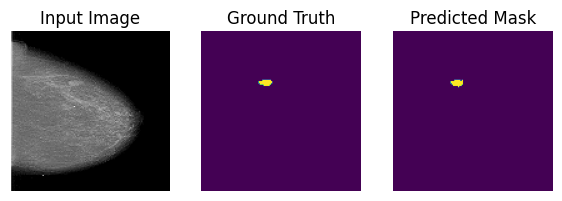

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
[0.0000000e+00 1.2210026e-38 1.3107744e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


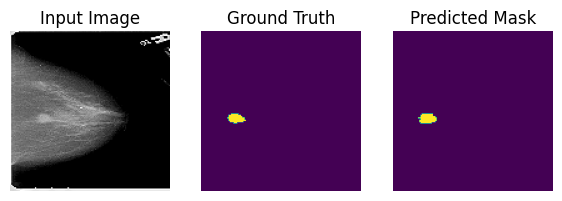

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
[0.0000000e+00 1.1959895e-38 1.2014402e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


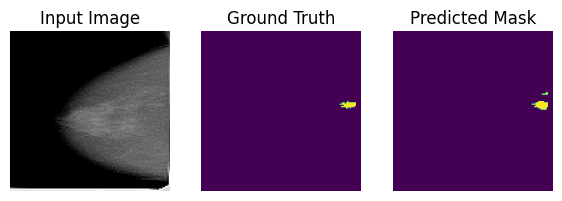

In [68]:
for image, mask in test_batches.take(3):
    pred_mask = loaded_model.predict(image)
    true_mask = mask[0] # tf.expand_dims(mask[0], axis=-1)
    
    display([image[0], true_mask, create_mask(pred_mask)])